In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
df = pd.read_csv("../data/processed/sf_housing_model_ready.csv")

df.head()

,unique_id,rent,sqft,bedrooms,bathrooms,property_age,price_per_sqft,sqft_per_bedroom,bath_bed_ratio,neighborhood,neighborhood_avg_rent,neighborhood_median_rent,neighborhood_avg_price_per_sqft,neighborhood_listing_count,rent_difference,rent_ratio,longitude,latitude
0,-8921002025303494677,1125.5,625.5,2.0,1.0,126.0,1.799361,312.75,0.500000,Mission,2296.018074,2125.5,3.722369,34165,-1170.518074,0.490196,-122.413262,37.752610
1,4926114481077084764,1125.5,625.5,2.0,1.0,126.0,1.799361,312.75,0.500000,Mission,2296.018074,2125.5,3.722369,34165,-1170.518074,0.490196,-122.413262,37.752610
2,-7607276172970613120,1875.5,625.5,2.0,1.0,126.0,2.998401,312.75,0.500000,Mission,2296.018074,2125.5,3.722369,34165,-420.518074,0.816849,-122.413262,37.752610
3,-3082667924758429561,2375.5,625.5,1.0,2.0,126.0,3.797762,625.50,2.000000,Mission,2296.018074,2125.5,3.722369,34165,79.481926,1.034617,-122.420380,37.752176
4,4677180230763728877,4875.5,1375.5,3.0,2.0,126.0,3.544529,458.50,0.666667,Pacific Heights,2945.786549,2875.5,4.304128,27395,1929.713451,1.655076,-122.432934,37.787143


In [4]:
df.info()

df.describe()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461298 entries, 0 to 461297
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   unique_id                        461298 non-null  int64  
 1   rent                             461298 non-null  float64
 2   sqft                             461298 non-null  float64
 3   bedrooms                         461298 non-null  float64
 4   bathrooms                        461298 non-null  float64
 5   property_age                     443596 non-null  float64
 6   price_per_sqft                   461298 non-null  float64
 7   sqft_per_bedroom                 461298 non-null  float64
 8   bath_bed_ratio                   461298 non-null  float64
 9   neighborhood                     461298 non-null  object 
 10  neighborhood_avg_rent            461298 non-null  float64
 11  neighborhood_median_rent         461298 non-null  float64
 12  ne

unique_id                              0
rent                                   0
sqft                                   0
bedrooms                               0
bathrooms                              0
property_age                       17702
price_per_sqft                         0
sqft_per_bedroom                       0
bath_bed_ratio                         0
neighborhood                           0
neighborhood_avg_rent                  0
neighborhood_median_rent               0
neighborhood_avg_price_per_sqft        0
neighborhood_listing_count             0
rent_difference                        0
rent_ratio                             0
longitude                              0
latitude                               0
dtype: int64

In [5]:
TARGET = "rent"

NUMERIC_FEATURES = [
    "sqft",
    "bedrooms",
    "bathrooms",
    "property_age",
    "longitude",
    "latitude"
]

CATEGORICAL_FEATURES = [
    "neighborhood"
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[FEATURES]

y = df[TARGET]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [8]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            NUMERIC_FEATURES
        ),
        (
            "cat",
            categorical_transformer,
            CATEGORICAL_FEATURES
        )
    ]
)

In [10]:
baseline_prediction = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

print(f"Baseline MAE: {baseline_mae:.2f}")

Baseline MAE: 958.77


In [11]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [12]:
linear_results = {
    "Model": "Linear Regression",
    "MAE": mean_absolute_error(y_test, linear_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, linear_pred)),
    "R2": r2_score(y_test, linear_pred)
}

linear_results

{'Model': 'Linear Regression',
 'MAE': 643.5803924368738,
 'RMSE': np.float64(860.7067827957386),
 'R2': 0.49610076170101336}

In [13]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [14]:
rf_results = {
    "Model": "Random Forest",
    "MAE": mean_absolute_error(y_test, rf_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "R2": r2_score(y_test, rf_pred)
}

rf_results

{'Model': 'Random Forest',
 'MAE': 444.3277691747875,
 'RMSE': np.float64(631.6969781889169),
 'R2': 0.7285743729683769}

In [15]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [16]:
gb_results = {
    "Model": "Gradient Boosting",
    "MAE": mean_absolute_error(y_test, gb_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, gb_pred)),
    "R2": r2_score(y_test, gb_pred)
}

gb_results

{'Model': 'Gradient Boosting',
 'MAE': 605.7081936868633,
 'RMSE': np.float64(807.3563527426809),
 'R2': 0.5566325716805454}

In [17]:
results = pd.DataFrame([
    linear_results,
    rf_results,
    gb_results
])

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
1,Random Forest,444.327769,631.696978,0.728574
2,Gradient Boosting,605.708194,807.356353,0.556633
0,Linear Regression,643.580392,860.706783,0.496101


In [18]:
feature_names = (
    rf_model.named_steps["preprocessor"]
            .get_feature_names_out()
)

importance = pd.Series(
    rf_model.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values()

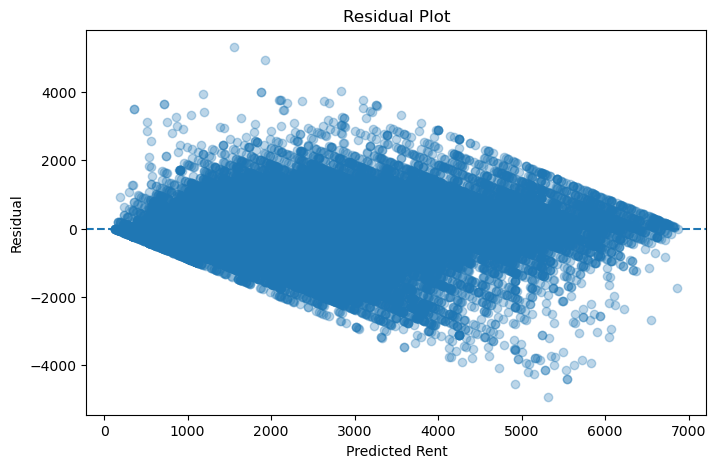

In [19]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

plt.scatter(rf_pred, residuals, alpha=0.3)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Rent")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [21]:
joblib.dump(
    rf_model,
    "../models/rent_prediction_model.pkl"
)

['../models/rent_prediction_model.pkl']